# E6 · Cost per useful output

**Optional decision:** Can compute become cheaper per useful task while the total bill rises? Read Notebook 1 first; allow 10–15 minutes. Our customer buys consumed GPU-hours at a hypothetical USD 4/hour. This is a usage-based purchase, not the reseller's committed-capacity rental model.

A useful output is one completed task meeting a fixed quality criterion. The same criterion applies before and after every change. It is not a token count, processor-utilization reading or revenue measure. Failed attempts, retries, capacity limits, power and financing are excluded; no actual hardware performance is claimed.

Start with 10,000 useful tasks requiring 0.01 GPU-hours each. Then distinguish efficiency, demand and workload mix. Categories must be mutually exclusive, so every useful task is counted exactly once. All performance and demand inputs are invented teaching assumptions.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from IPython.display import display

from liquid_compute.education import (
    explore_workload_mix,
    plot_workload_comparison,
    show_finance_table,
)
from liquid_compute.workload_costs import decompose_workload_spend, useful_output_costs

price = 4.0
base_count = 10_000
base_intensity = 0.01
print(
    "Customer pays only for consumed GPU-hours; useful-task quality criterion held fixed."
)

Customer pays only for consumed GPU-hours; useful-task quality criterion held fixed.


## Work unit cost and total spend separately

Baseline consumption is 10,000 × 0.01 = 100 GPU-hours, costing USD 400. Divide by 10,000 useful tasks to get USD 0.04/task.

Now reduce intensity to 0.008 GPU-hours/task but increase demand to 15,000 tasks. Consumption becomes 120 hours and spend USD 480; unit cost falls to USD 0.032/task. The 20% efficiency improvement is outweighed in total spend by 50% more tasks. Lower unit cost and a lower budget are different outcomes.

In [3]:
direct_hours = base_count * base_intensity
direct_cost = direct_hours * price
changed_hours = 15_000 * 0.008
changed_cost = changed_hours * price
show_finance_table(
    ["Direct case", "Useful tasks", "GPU-hours", "Spend USD", "USD/task"],
    [
        ["Baseline", base_count, direct_hours, direct_cost, direct_cost / base_count],
        [
            "Efficient plus more demand",
            15_000,
            changed_hours,
            changed_cost,
            f"{changed_cost / 15_000:.3f}",
        ],
    ],
)
print(
    f"Unit costs: USD {direct_cost / base_count:.3f} to USD {changed_cost / 15_000:.3f} per task"
)
single_base = useful_output_costs(
    task_counts={"task": base_count},
    gpu_hours_per_task={"task": base_intensity},
    usd_per_gpu_hour=price,
)

| Direct case | Useful tasks | GPU-hours | Spend USD | USD/task |
| --- | --- | --- | --- | --- |
| Baseline | 10,000.00 | 100.00 | 400.00 | 0.04 |
| Efficient plus more demand | 15,000.00 | 120.00 | 480.00 | 0.032 |

Unit costs: USD 0.040 to USD 0.032 per task


## Introduce two disjoint workloads

For a separate mix example, light tasks require 0.005 GPU-hours and heavy tasks 0.02. At 80% light and 20% heavy, weighted intensity is 0.8 × 0.005 + 0.2 × 0.02 = 0.008 hours/task. At 10,000 tasks, spend is USD 320.

Weight by task counts; averaging the two category unit costs without those weights would implicitly assume a 50/50 mix. Keep both categories present even if a scenario gives one zero count. Their names and quality definitions must stay stable across comparisons.

In [4]:
intensities = {"light": 0.005, "heavy": 0.02}
base_mix_counts = {"light": 8_000, "heavy": 2_000}
weighted_intensity = 0.8 * intensities["light"] + 0.2 * intensities["heavy"]
base_mix = useful_output_costs(
    task_counts=base_mix_counts, gpu_hours_per_task=intensities, usd_per_gpu_hour=price
)
show_finance_table(
    ["Workload", "Tasks", "GPU-hours/task", "Consumed GPU-hours", "Cost USD"],
    [
        [
            name,
            count,
            f"{intensities[name]:.4f}",
            count * f"{intensities[name]:.4f}",
            count * intensities[name] * price,
        ]
        for name, count in base_mix_counts.items()
    ],
)
print(
    f"Weighted intensity {weighted_intensity:.4f}; total USD {base_mix.total_cost_usd:.2f}; unit USD {base_mix.usd_per_task:.3f}/task"
)

| Workload | Tasks | GPU-hours/task | Consumed GPU-hours | Cost USD |
| --- | --- | --- | --- | --- |
| light | 8,000.00 | 0.0050 | 0.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.00500.0050 | 160.00 |
| heavy | 2,000.00 | 0.0200 | 0.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.02000.0200 | 160.00 |

Weighted intensity 0.0080; total USD 320.00; unit USD 0.032/task


## Compare budget and unit cost on separate axes

The charts keep total USD and USD/task separate rather than plotting incompatible units on one scale. Controls change total demand and the heavy-workload fraction, with light share defined as one minus heavy share. The fractions therefore sum to one.

The initial baseline is frozen inside the explorer; changes do not modify fixed experiments below. At zero tasks, spend is zero and unit cost is N/A, not zero. A per-task ratio has no denominator in that case. Editable assumptions and the static comparison provide the same lesson without widgets.

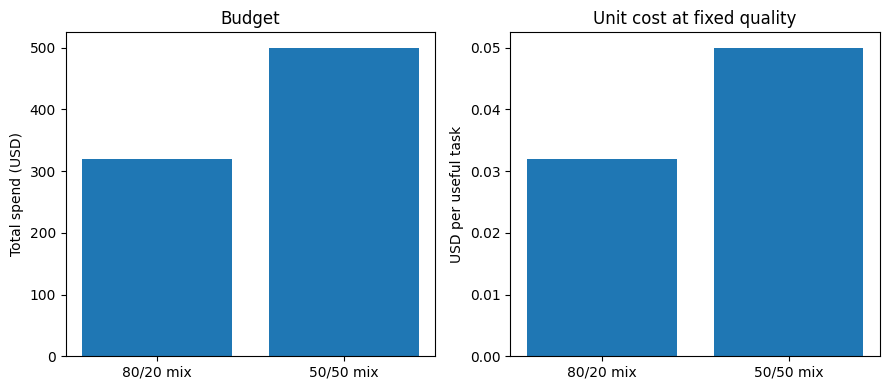

In [5]:
mix_50 = useful_output_costs(
    task_counts={"light": 5_000, "heavy": 5_000},
    gpu_hours_per_task=intensities,
    usd_per_gpu_hour=price,
)
display(plot_workload_comparison({"80/20 mix": base_mix, "50/50 mix": mix_50}))
explore_workload_mix(
    task_count=10_000,
    heavy_fraction=0.2,
    light_gpu_hours_per_task=0.005,
    heavy_gpu_hours_per_task=0.02,
    usd_per_gpu_hour=4,
);

The 50/50 mix costs USD 500 and USD 0.05/task, versus USD 320 and USD 0.032/task at 80/20. Neither category became less efficient; more tasks came from the more intensive category.

## Experiment 1 · Improve efficiency only

Return to the single-workload baseline for a clean comparison. Hold 10,000 tasks and USD 4/hour fixed, while lowering intensity from 0.01 to 0.008. The same quality-qualified outputs require less consumed compute. This is an assumed productivity change, not a claim about a particular model or GPU.

In [6]:
efficient_only = useful_output_costs(
    task_counts={"task": 10_000},
    gpu_hours_per_task={"task": 0.008},
    usd_per_gpu_hour=price,
)
show_finance_table(
    ["Case", "Tasks", "GPU-hours", "Spend USD", "USD/task"],
    [
        [
            name,
            r.useful_tasks,
            r.consumed_gpu_hours,
            r.total_cost_usd,
            f"{r.usd_per_task:.3f}",
        ]
        for name, r in [("Baseline", single_base), ("Efficiency only", efficient_only)]
    ],
)

| Case | Tasks | GPU-hours | Spend USD | USD/task |
| --- | --- | --- | --- | --- |
| Baseline | 10,000.00 | 100.00 | 400.00 | 0.040 |
| Efficiency only | 10,000.00 | 80.00 | 320.00 | 0.032 |

Consumption falls from 100 to 80 hours and spend from USD 400 to USD 320. Both total and unit cost fall 20% because demand was held fixed.

## Experiment 2 · Add demand growth

Keep improved intensity at 0.008 but raise volume by 50%, to 15,000 tasks. Compared with the original baseline, the consumption multiplier is 1.5 × 0.8 = 1.2. The bill therefore rises 20% despite the lower unit cost.

This arithmetic does not establish that efficiency caused demand growth. Volume and intensity are independently specified scenario inputs. A business forecast would need separate evidence.

In [7]:
efficient_growth = useful_output_costs(
    task_counts={"task": 15_000},
    gpu_hours_per_task={"task": 0.008},
    usd_per_gpu_hour=price,
)
show_finance_table(
    ["Case", "Tasks", "GPU-hours", "Spend USD", "USD/task"],
    [
        [
            name,
            r.useful_tasks,
            r.consumed_gpu_hours,
            r.total_cost_usd,
            f"{r.usd_per_task:.3f}",
        ]
        for name, r in [
            ("Original", single_base),
            ("Efficient plus growth", efficient_growth),
        ]
    ],
)
print(
    f"Spend change {(efficient_growth.total_cost_usd / single_base.total_cost_usd - 1):.0%}; unit change {(efficient_growth.usd_per_task / single_base.usd_per_task - 1):.0%}"
)

| Case | Tasks | GPU-hours | Spend USD | USD/task |
| --- | --- | --- | --- | --- |
| Original | 10,000.00 | 100.00 | 400.00 | 0.040 |
| Efficient plus growth | 15,000.00 | 120.00 | 480.00 | 0.032 |

Spend change 20%; unit change -20%


The result returns to USD 480 total and USD 0.032/task. Reporting only unit efficiency would miss the additional USD 80 budget requirement.

## Experiment 3 · Attribute a mix shift in a stated order

Return to the two-workload example and shift 80/20 to 50/50 at unchanged total volume, intensities and price. Replace inputs in the fixed order **volume → mix → intensity → price**. The resulting contributions sum to the actual spend change.

Here only mix changes, so the USD 180 increase is entirely a mix effect. When several inputs change together, the attribution depends on replacement order even though the total difference remains the same. This is an accounting decomposition of scenarios, not proof of causation.

In [8]:
mix_decomposition = decompose_workload_spend(
    before_task_counts=base_mix_counts,
    after_task_counts={"light": 5_000, "heavy": 5_000},
    before_gpu_hours_per_task=intensities,
    after_gpu_hours_per_task=intensities,
    before_usd_per_gpu_hour=price,
    after_usd_per_gpu_hour=price,
)
show_finance_table(
    ["Ordered contribution", "USD"],
    [
        ["Volume", mix_decomposition.volume_usd],
        ["Mix", mix_decomposition.mix_usd],
        ["Intensity", mix_decomposition.intensity_usd],
        ["Price", mix_decomposition.price_usd],
        ["Total spend change", mix_decomposition.total_change_usd],
        ["Reconciliation residual", mix_decomposition.reconciliation_residual_usd],
    ],
)

| Ordered contribution | USD |
| --- | --- |
| Volume | 0.00 |
| Mix | 180.00 |
| Intensity | 0.00 |
| Price | 0.00 |
| Total spend change | 180.00 |
| Reconciliation residual | 0.00 |

The decomposition gives zero volume, intensity and price effects, USD 180 mix effect, and zero residual. Weighted intensity rises from 0.008 to 0.0125 hours/task solely because heavy tasks receive more weight.

## Decide which outcome matters

Compare the previously calculated single-workload cases. A procurement team watching USD/GPU-hour, an engineering team watching GPU-hours/task and a budget owner watching total USD can see different outcomes without any contradiction. Keep the output definition, workload mix and demand visible alongside unit efficiency.

In [9]:
show_finance_table(
    ["Single-workload case", "Total spend USD", "Unit cost USD/task"],
    [
        [name, r.total_cost_usd, f"{r.usd_per_task:.3f}"]
        for name, r in [
            ("Baseline", single_base),
            ("Efficiency only", efficient_only),
            ("Efficiency and growth", efficient_growth),
        ]
    ],
)
print(
    "Unit costs retain precision: "
    + ", ".join(
        f"{r.usd_per_task:.3f}" for r in (single_base, efficient_only, efficient_growth)
    )
)

| Single-workload case | Total spend USD | Unit cost USD/task |
| --- | --- | --- |
| Baseline | 400.00 | 0.040 |
| Efficiency only | 320.00 | 0.032 |
| Efficiency and growth | 480.00 | 0.032 |

Unit costs retain precision: 0.040, 0.032, 0.032


**Next:** return to the core track or use this demand lens in the planned C1 transaction capstone only when relevant. No capstone is implemented here.

Useful-task productivity differs from Notebook 1's billed-capacity utilization and E3's technical power draw. No real benchmark, quality improvement, dollars-per-token claim or external performance dataset is introduced. Real comparisons would need controlled hardware/software configuration and a consistent quality criterion; these hypothetical examples require no external data.